# IBM Telco Customer Churn — Data Cleaning

**Dataset:** IBM Telco Customer Churn (7,043 customers × 33 features)  
**Goal:** Produce a clean, model-ready dataset by resolving type issues, removing leakage, eliminating zero-variance columns, and standardizing formatting.  
**Output:** `data/telco_churn_clean.csv`

---

## Cleaning Roadmap

| Step | Task | Issue Found |
|------|------|-------------|
| 1 | Load & inspect | Shape, dtypes, nulls, cardinality |
| 2 | Fix dtype — `Total Charges` | Stored as `object`; 11 zero-tenure rows dropped (0.15% of data) |
| 3 | Handle nulls — `Churn Reason` | 5,174 nulls (expected: only churned customers have a reason) |
| 4 | Drop zero-variance columns | `Count`, `Country`, `State` — constant across all rows |
| 5 | Drop geographic columns | `Lat Long`, `Latitude`, `Longitude`, `City`, `Zip Code` — not predictive |
| 6 | Drop data-leakage columns | `Churn Score`, `CLTV`, `Churn Reason`, `Churn Label` |
| 6b | Extract & drop `CustomerID` | Identifier — not a feature; saved separately for prediction mapping |
| 7 | Standardize column names | Lowercase, underscores — consistent and import-friendly |
| 8 | Encode categorical columns | Binary Yes/No → 1/0; defer multi-class to modeling pipeline |
| 9 | Feature engineering | Derive `charges_per_month` and `addon_count` |
| 10 | Final validation | Confirm shape, dtypes, zero nulls, column list |
| 11 | Save clean file | `data/telco_churn_clean.csv` |

---
## Step 1 — Imports & Load Data

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Reproducibility & display settings
np.random.seed(42)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [88]:
df = pd.read_excel("data/Telco_customer_churn.xlsx")

In [89]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


---
## Step 1b — Initial Inspection

We run three diagnostics before touching anything:
1. **`.info()`** — column names, dtypes, and non-null counts at a glance
2. **`.isnull().sum()`** — find every column with missing values
3. **`.nunique()`** — spot zero-variance (constant) and high-cardinality columns

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [91]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [92]:
# We compute the % so we can decide: impute, drop, or keep as-is.
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_report = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_pct
})
null_report[null_report['Null Count'] > 0]

,Null Count,Null %
Churn Reason,5174,73.46


In [93]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

---
## Step 2 — Fix `Total Charges` dtype

**Problem:** `Total Charges` is stored as `object` (string) instead of `float64`.  
**Root cause:** Rows where `Tenure Months == 0` (brand-new customers) have a whitespace string `" "` instead of a number — pandas cannot infer the column as numeric because of these entries.  
**Fix:** Use `pd.to_numeric(..., errors='coerce')` to force conversion; whitespace strings become `NaN`.

### Handling the 11 new-customer nulls

After coercion, 11 rows have `NaN` in `Total Charges` — all are customers with `Tenure Months == 0`. There are three defensible approaches:

| Option | What it does | Trade-off |
|--------|-------------|----------|
| **Fill with `0`** | Sets `total_charges = 0` for new customers | The combination `monthly_charges > 0` AND `total_charges = 0` is a data artifact, not a real pattern. A model might learn a spurious rule from it |
| **Drop the 11 rows** | Removes new customers from the dataset entirely | Loses 11 rows out of 7,043 (0.15%) — negligible. Cleanest option if new-customer behavior isn't the focus |
| **Impute with `monthly_charges`** | Estimates total ≈ monthly for a first partial month | More honest than 0, avoids the spurious signal, but still an approximation |

**Decision:** We drop the 11 rows. The loss is negligible (0.15% of data), it avoids introducing a spurious `total_charges = 0` signal, and it keeps the dataset clean without requiring an extra engineered flag.  
> If new-customer churn were a specific business question, the right approach would be to fill with `0` and add an `is_new_customer` flag to let the model distinguish this artifact from a genuine zero-spend pattern — but that belongs in feature engineering, not cleaning.

In [94]:
# Confirm the issue: check rows where Total Charges is not numeric
# Strip whitespace and check for blank strings
problematic = df[df['Total Charges'].astype(str).str.strip() == '']
print(f"Rows with blank Total Charges: {len(problematic)}")

# Are these all new customers (Tenure Months == 0)?
print("Tenure distribution for these rows:")
print(problematic['Tenure Months'].value_counts())

Rows with blank Total Charges: 11
Tenure distribution for these rows:
Tenure Months
0    11
Name: count, dtype: int64


In [95]:
# Coerce to numeric — whitespace strings become NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

nulls_after = df['Total Charges'].isnull().sum()
print(f"Nulls after coercion: {nulls_after} (all are tenure_months == 0 customers)")

# Show the affected rows before dropping
print("\nAffected rows:")
print(df[df['Total Charges'].isnull()][['Tenure Months', 'Monthly Charges', 'Total Charges']].to_string())

# ------------------------------------------------------------------
# Decision: drop these 11 rows.
# Filling with 0 would create a spurious signal: monthly_charges > 0
# but total_charges = 0 — a combination that doesn't exist for any
# real customer. Dropping 11 rows out of 7,043 (0.15%) is negligible.
# ------------------------------------------------------------------
df = df.dropna(subset=['Total Charges'])

print(f"\ndtype after fix: {df['Total Charges'].dtype}")
print(f"Remaining nulls in Total Charges: {df['Total Charges'].isnull().sum()}")
print(f"Rows remaining: {len(df):,}")

Nulls after coercion: 11 (all are tenure_months == 0 customers)

Affected rows:
      Tenure Months  Monthly Charges  Total Charges
2234              0            52.55            NaN
2438              0            20.25            NaN
2568              0            80.85            NaN
2667              0            25.75            NaN
2856              0            56.05            NaN
4331              0            19.85            NaN
4687              0            25.35            NaN
5104              0            20.00            NaN
5719              0            19.70            NaN
6772              0            73.35            NaN
6840              0            61.90            NaN

dtype after fix: float64
Remaining nulls in Total Charges: 0
Rows remaining: 7,032


---
## Step 3 — `Churn Reason` Nulls: Expected, Not a Problem

**Observation:** `Churn Reason` has 5,174 nulls (~73% of rows).  
**Why this is fine:** Only customers who churned (`Churn Value == 1`) have a reason. Non-churned customers never fill this field — it's a structural null, not a data quality issue.  
**Decision:** We will drop this column entirely later anyway (it's post-churn information = data leakage), but it's important to document the reasoning.

In [96]:
# Verify: all non-null Churn Reason rows are churned customers
has_reason = df['Churn Reason'].notna()
is_churned = df['Churn Value'] == 1

print(f"Rows with a Churn Reason:      {has_reason.sum()}")
print(f"Total churned customers:       {is_churned.sum()}")
print(f"All reason-rows are churned:   {(has_reason & is_churned).sum() == has_reason.sum()}")

# Confirm: non-churned customers NEVER have a reason
non_churned_with_reason = df[(df['Churn Value'] == 0) & df['Churn Reason'].notna()]
print(f"Non-churned customers with a reason (should be 0): {len(non_churned_with_reason)}")

Rows with a Churn Reason:      1869
Total churned customers:       1869
All reason-rows are churned:   True
Non-churned customers with a reason (should be 0): 0


---
## Step 4 — Drop Zero-Variance Columns

A column with only one unique value carries **zero information** for a model — it cannot help predict anything. Including these adds noise, memory overhead, and confusion.

| Column | Unique Values | Why Drop |
|--------|--------------|----------|
| `Count` | 1 | Always equals 1 for every row |
| `Country` | 1 | Always `"United States"` |
| `State` | 1 | Always `"California"` |

In [97]:
# Confirm zero-variance before dropping
zero_var_cols = ['Count', 'Country', 'State']
print("Unique values in zero-variance columns:")
for col in zero_var_cols:
    print(f"  {col}: {df[col].unique()}")

Unique values in zero-variance columns:
  Count: [1]
  Country: ['United States']
  State: ['California']


In [98]:
df.drop(columns=zero_var_cols, inplace=True)
print(f"Shape after dropping zero-variance columns: {df.shape}")

Shape after dropping zero-variance columns: (7032, 30)


---
## Step 5 — Drop Geographic Columns

Geographic features at this granularity are not useful for churn prediction:

| Column | Reason to Drop |
|--------|----------------|
| `Lat Long` | Redundant string combining Latitude + Longitude |
| `Latitude` | Continuous GPS coordinate — no predictive signal for churn |
| `Longitude` | Same as above |
| `City` | 1,129 unique values — too high cardinality without feature engineering; out of scope for this phase |
| `Zip Code` | 1,652 unique values — too high cardinality without feature engineering; out of scope for this phase |
>Note : City was dropped due to high cardinality (1,129 unique values). If geographic signal is desired, a future feature engineering step could cluster cities into regions using population density or service area data.

In [99]:
geo_cols = ['Lat Long', 'Latitude', 'Longitude', 'City', 'Zip Code']

# Quick sanity check before drop
print(f"Zip Code unique values: {df['Zip Code'].nunique()} (out of {len(df)} rows)")
print(f"City unique values: {df['City'].nunique()} (out of {len(df)} rows)")

df.drop(columns=geo_cols, inplace=True)
print(f"Shape after dropping geographic columns: {df.shape}")

Zip Code unique values: 1652 (out of 7032 rows)
City unique values: 1129 (out of 7032 rows)
Shape after dropping geographic columns: (7032, 25)


---
## Step 6 — Drop Data Leakage Columns

**This is the most critical step for model integrity.**

Data leakage occurs when information that would not be available at prediction time is included in the training data. A model trained on leaked features will show unrealistically high performance in training/testing but will fail completely in production.

| Column | Why It's Leakage / Redundant |
|--------|------------------------------|
| `Churn Label` | Exact string duplicate of `Churn Value` (our target). Keeping both would trivially leak the label |
| `Churn Score` | IBM-generated churn probability — this *is* the prediction. Training on it is circular |
| `CLTV` | IBM-generated Customer Lifetime Value score — derived from churn likelihood, same issue |
| `Churn Reason` | Recorded *after* a customer has already churned. Unavailable at prediction time |

In [100]:
# Confirm Churn Label is a duplicate of Churn Value before dropping
label_value_match = (df['Churn Label'].map({'Yes': 1, 'No': 0}) == df['Churn Value']).all()
print(f"Churn Label perfectly mirrors Churn Value: {label_value_match}")

Churn Label perfectly mirrors Churn Value: True


In [101]:
leakage_cols = ['Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']
df.drop(columns=leakage_cols, inplace=True)
print(f"Shape after dropping leakage columns: {df.shape}")

Shape after dropping leakage columns: (7032, 21)


---
## Step 6b — Extract & Drop `CustomerID`

`CustomerID` is a row identifier, not a feature. Including it in model training would cause the model to memorize specific customer IDs rather than learning generalizable patterns — it carries zero predictive signal for new, unseen customers.

**However**, we don't simply discard it. We save it as a separate Series so we can later map model predictions back to real customers (e.g. *"Customer 3668-QPYBK has a 78% churn probability"*). This is essential for any business-facing output and shows end-to-end pipeline thinking.

In [102]:
# ------------------------------------------------------------------
# Save CustomerID before dropping — we'll need it later to attach
# predictions back to real customers in the deployment/reporting phase.
# ------------------------------------------------------------------
customer_ids = df['CustomerID'].copy()
print(f"CustomerID preserved: {len(customer_ids):,} entries")
print(f"Sample IDs: {customer_ids.head(3).tolist()}")

# Now safe to drop — it's an identifier, not a predictive feature
df.drop(columns=['CustomerID'], inplace=True)
print(f"Shape after dropping CustomerID: {df.shape}")

CustomerID preserved: 7,032 entries
Sample IDs: ['3668-QPYBK', '9237-HQITU', '9305-CDSKC']
Shape after dropping CustomerID: (7032, 20)


---
## Step 7 — Standardize Column Names

Column names with spaces cause friction: you cannot use `df.column_name` dot notation, and they break many SQL tools and ML pipeline APIs. We convert all names to lowercase with underscores — a widely adopted convention in Python data science.

In [103]:
# Before
print("Before:")
print(df.columns.tolist())

Before:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [104]:
# strip() removes leading/trailing spaces
# lower() converts to lowercase
# str.replace(' ', '_') replaces spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("After:")
print(df.columns.tolist())

After:
['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_value']


---
## Step 8 — Encode categorical columns

**Binary Yes/No columns** are encoded directly here (1/0) — they are unambiguous and encoding now keeps the clean CSV model-ready.

**Multi-class columns** (`internet_service`, `contract`, `payment_method`) are left as strings and will be one-hot encoded inside a `sklearn Pipeline` in the modeling notebook. This prevents data leakage from fitting an encoder on the full dataset before the train/test split.

> **Encoding decision documented:** Binary → here. Multi-class → modeling pipeline.

In [105]:
df.nunique().sort_values()

gender                  2
senior_citizen          2
partner                 2
dependents              2
phone_service           2
paperless_billing       2
churn_value             2
internet_service        3
tech_support            3
online_security         3
device_protection       3
online_backup           3
streaming_movies        3
streaming_tv            3
contract                3
multiple_lines          3
payment_method          4
tenure_months          72
monthly_charges      1584
total_charges        6530
dtype: int64

In [106]:
# Binary columns: Yes → 1, No → 0
# Columns with 'No phone service' or 'No internet service' are also treated as 0
binary_yes_no = [
    'gender', 'senior_citizen', 'partner', 'dependents',
    'phone_service', 'paperless_billing'
]

# Service columns that may contain 'No phone service' / 'No internet service'
service_cols = [
    'multiple_lines', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'
]

# Gender: Female → 1, Male → 0
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Standard Yes/No binary columns
for col in ['senior_citizen', 'partner', 'dependents', 'phone_service', 'paperless_billing']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Service columns: Yes → 1, everything else (No, No phone service, No internet service) → 0
for col in service_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Verify encoding
encoded_cols = ['gender', 'partner', 'dependents'] + service_cols
print("Binary encoding complete. Unique values check:")
for col in encoded_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

Binary encoding complete. Unique values check:
  gender: [np.int64(0), np.int64(1)]
  partner: [np.int64(0), np.int64(1)]
  dependents: [np.int64(0), np.int64(1)]
  multiple_lines: [np.int64(0), np.int64(1)]
  online_security: [np.int64(0), np.int64(1)]
  online_backup: [np.int64(0), np.int64(1)]
  device_protection: [np.int64(0), np.int64(1)]
  tech_support: [np.int64(0), np.int64(1)]
  streaming_tv: [np.int64(0), np.int64(1)]
  streaming_movies: [np.int64(0), np.int64(1)]


In [107]:
# Multi-class columns — left as strings for pipeline encoding
multi_class_cols = ['internet_service', 'contract', 'payment_method']
print("Multi-class columns (deferred to modeling pipeline):")
for col in multi_class_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

Multi-class columns (deferred to modeling pipeline):
  internet_service: ['DSL', 'Fiber optic', 'No']
  contract: ['Month-to-month', 'Two year', 'One year']
  payment_method: ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']


---
## Step 9 — Feature Engineering

Two derived features that frequently rank highly in feature importance:

| Feature | Formula | Business meaning |
|---------|----------|------------------|
| `charges_per_month` | `total_charges / tenure_months` | Average spend per month — smooths the relationship between charges and tenure |
| `addon_count` | Sum of 6 service flags | How 'sticky' a customer is — more add-ons = more switching cost |

In [108]:
# Feature 1: Average monthly spend (normalises total_charges by tenure)
df['charges_per_month'] = (df['total_charges'] / df['tenure_months']).round(2)

# Feature 2: Number of add-on services subscribed
addon_cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]
df['addon_count'] = df[addon_cols].sum(axis=1)

print("New features added:")
print(df[['charges_per_month', 'addon_count']].describe())

New features added:
       charges_per_month  addon_count
count            7032.00      7032.00
mean               64.80         2.04
std                30.19         1.85
min                13.78         0.00
25%                36.18         0.00
50%                70.38         2.00
75%                90.18         3.00
max               121.40         6.00


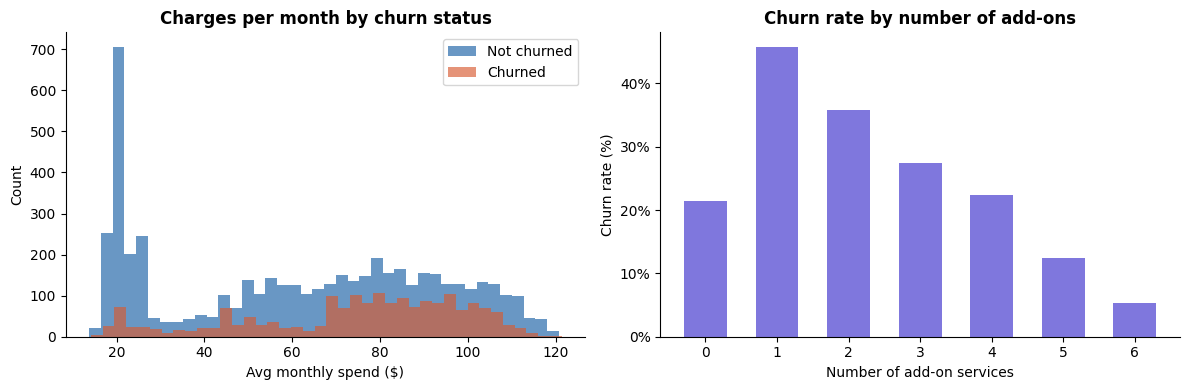

In [109]:
# Visualise engineered features vs churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# charges_per_month by churn
for val, label, color in [(0, 'Not churned', '#185FA5'), (1, 'Churned', '#D85A30')]:
    axes[0].hist(
        df[df['churn_value'] == val]['charges_per_month'],
        bins=40, alpha=0.65, label=label, color=color, edgecolor='none'
    )
axes[0].set_title('Charges per month by churn status', fontweight='bold')
axes[0].set_xlabel('Avg monthly spend ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# addon_count by churn
churn_by_addon = df.groupby('addon_count')['churn_value'].mean() * 100
axes[1].bar(churn_by_addon.index, churn_by_addon.values, color='#7F77DD', width=0.6)
axes[1].set_title('Churn rate by number of add-ons', fontweight='bold')
axes[1].set_xlabel('Number of add-on services')
axes[1].set_ylabel('Churn rate (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

sns.despine()
plt.tight_layout()
plt.savefig('data/chart_engineered_features.png', dpi=130, bbox_inches='tight')
plt.show()

In [110]:
print("Customers with 0 add-ons churn at {:.1f}% vs {:.1f}% for 6 add-ons.".format(
    churn_by_addon[0], churn_by_addon[6]
))

Customers with 0 add-ons churn at 21.5% vs 5.3% for 6 add-ons.


>Insight: More add-ons = significantly lower churn rate.

---
## Step 10 — Final Validation

Before saving, we run a complete quality check to confirm:
-  No remaining nulls in any column
-  All numeric columns have correct dtypes
-  Target column (`churn_value`) is binary (0/1)
-  No duplicate rows
-  Dataset dimensions match expectations

In [111]:
# Final shape
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns removed: {33 - df.shape[1]} (from 33 to {df.shape[1]})")

Final shape: 7,032 rows × 22 columns
Columns removed: 11 (from 33 to 22)


In [112]:
# Null check — should be 0 for all columns
final_nulls = df.isnull().sum()
if final_nulls.sum() == 0:
    print("No null values remaining.")
else:
    print("Nulls still present:")
    print(final_nulls[final_nulls > 0])

No null values remaining.


In [113]:
# Duplicate check
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"  → Dropped. New shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicate rows: 22
  → Dropped. New shape: (7010, 22)


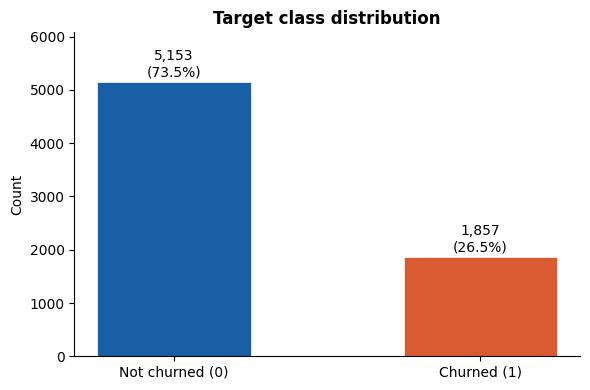

In [114]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = df['churn_value'].value_counts().sort_index()
target_pct = df['churn_value'].value_counts(normalize=True).sort_index() * 100
colors = ['#185FA5', '#D85A30']
bars = ax.bar(['Not churned (0)', 'Churned (1)'], target_counts, color=colors,
              edgecolor='white', linewidth=0.5, width=0.5)
for i, (v, pct) in enumerate(zip(target_counts, target_pct)):
    ax.text(i, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Target class distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, target_counts.max() * 1.18)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('data/class_distribution_init.png', dpi=130, bbox_inches='tight')
plt.show()

>Note: Dataset is imbalanced (~26% churn).

In [115]:
# Final dtype summary
print("Final dtypes:")
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)
print()
df.info()

Final dtypes:
int64      16
object      3
float64     3
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7010 non-null   int64  
 1   senior_citizen     7010 non-null   int64  
 2   partner            7010 non-null   int64  
 3   dependents         7010 non-null   int64  
 4   tenure_months      7010 non-null   int64  
 5   phone_service      7010 non-null   int64  
 6   multiple_lines     7010 non-null   int64  
 7   internet_service   7010 non-null   object 
 8   online_security    7010 non-null   int64  
 9   online_backup      7010 non-null   int64  
 10  device_protection  7010 non-null   int64  
 11  tech_support       7010 non-null   int64  
 12  streaming_tv       7010 non-null   int64  
 13  streaming_movies   7010 non-null   int64  
 14  contract           7010 non-null   object 

In [116]:
# Quick statistical summary of numeric columns
df.describe()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,churn_value,charges_per_month,addon_count
count,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00,7010.00
mean,0.50,0.16,0.48,0.23,32.52,0.90,0.42,0.29,0.35,0.34,0.29,0.39,0.39,0.59,64.89,2290.35,0.26,64.89,2.04
std,0.50,0.37,0.50,0.42,24.52,0.30,0.49,0.45,0.48,0.48,0.45,0.49,0.49,0.49,30.06,2266.82,0.44,30.17,1.85
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.00,13.78,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.75,408.31,0.00,36.46,0.00
50%,0.00,0.00,0.00,0.00,29.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.40,1403.88,0.00,70.50,2.00
75%,1.00,0.00,1.00,0.00,56.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.90,3807.84,1.00,90.25,3.00
max,1.00,1.00,1.00,1.00,72.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,1.00,121.40,6.00


---
## Step 9 — Save Clean Dataset

In [117]:
output_path = 'data/telco_churn_clean.csv'
df.to_csv(output_path, index=False)
print(f"Clean dataset saved to: {output_path}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

Clean dataset saved to: data/telco_churn_clean.csv
   Rows: 7,010
   Columns: 22


---
## Summary of All Changes Made

| Action | Column(s) | Rationale |
|--------|-----------|-----------|
| **Type fix + row drop** | `Total Charges` | Coerced from `object` to `float64`; 11 zero-tenure rows dropped (filling with 0 would create a spurious `monthly_charges > 0` AND `total_charges = 0` signal) |
| **Documented structural nulls** | `Churn Reason` | 73% null by design — only churned customers have a reason |
| **Dropped — zero variance** | `Count`, `Country`, `State` | Single unique value across all 7,043 rows |
| **Dropped — not predictive** | `Lat Long`, `Latitude`, `Longitude`, `City`, `Zip Code` | GPS and zip data don't contribute to churn prediction without deeper geo feature engineering |
| **Dropped — data leakage** | `Churn Label`, `Churn Score`, `CLTV`, `Churn Reason` | These are either duplicates of the target or IBM-generated post-hoc scores unavailable at prediction time |
| **Extracted & dropped** | `CustomerID` | Row identifier — saved as `customer_ids` Series for prediction mapping; not a predictive feature |
| **Renamed columns** | All 33 → snake_case | Lowercase + underscores for consistent, dot-accessible, pipeline-compatible naming |

**Result:** 33 columns → **22 clean, model-ready columns**  
**Next step:** Exploratory Data Analysis (EDA) — distribution plots, correlation analysis, churn patterns by feature.

---
*Author: Hajar Aitlakssir | IBM Telco Churn Project*